# Thư viện

In [3]:
!pip install optuna

In [4]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.utils.weight_norm as weight_norm
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import math
from scipy.stats import kurtosis
from sklearn.preprocessing import MinMaxScaler
from torch.nn.utils.parametrizations import weight_norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
import csv
import os
import seaborn as sns
from sklearn.metrics import mean_absolute_error, confusion_matrix

# Thiết lập thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Using device: {device}")

💻 Using device: cuda


# Tiền xử lý

In [5]:
# Thông số từ tài liệu IEEE PHM 2012
TIME_STEP = 10  # Mỗi file acc_xxxxx.csv cách nhau 10 giây

# Nhãn RUL thực tế cho tập Test (Table 3 trong tài liệu)
test_actual_ruls = {
    'Bearing1_3': 5730, 'Bearing1_4': 339, 'Bearing1_5': 1610,
    'Bearing1_6': 1460, 'Bearing1_7': 7570, 'Bearing2_3': 7530,
    'Bearing2_4': 1390, 'Bearing2_5': 3090, 'Bearing2_6': 1290,
    'Bearing2_7': 580, 'Bearing3_3': 820
}

In [6]:
def extract_features(file_path):
    """Trích xuất chỉ số sức khỏe từ 2560 mẫu rung động."""
    try:
        # Cột 5: Ngang (Horiz), Cột 6: Dọc (Vert)
        df = pd.read_csv(file_path, header=None)
        h_acc = df.iloc[:, 4].values
        v_acc = df.iloc[:, 5].values

        return {
            'h_rms': np.sqrt(np.mean(h_acc**2)),
            'v_rms': np.sqrt(np.mean(v_acc**2)),
            'h_kurt': kurtosis(h_acc),
            'v_kurt': kurtosis(v_acc),
            'h_peak': np.max(np.abs(h_acc)),
            'v_peak': np.max(np.abs(v_acc))
        }
    except:
        return None

In [7]:
def calculate_exponential_hi(current_step, total_steps):
    """
    Tính HI từ 1.0 (mới) về 0.0 (hỏng) theo hàm mũ.
    Phù hợp với đặc tính hư hỏng của PRONOSTIA.
    """
    # Chuẩn hóa thời gian t từ 0 đến 1
    t = current_step / total_steps
    # Tham số lambda thường chọn khoảng 3-5 để tạo độ dốc cuối đời
    lambd = 4
    hi = (np.exp(lambd) - np.exp(lambd * t)) / (np.exp(lambd) - 1)
    return max(0, hi)

In [ ]:
def process_data(base_path, bearing_list, is_test=False):
    bearing_records = []
    for b_name in bearing_list:
        folder_path = os.path.join(base_path, b_name)
        files = sorted([f for f in os.listdir(folder_path) if f.startswith('acc')])

        # Tổng vòng đời = số file hiện có + số file tương ứng RUL thực tế (nếu là tập Test)
        actual_rul = test_actual_ruls.get(b_name, 0) if is_test else 0
        total_life_steps = len(files) + (actual_rul // TIME_STEP)

        cond = 1 if 'Bearing1' in b_name else (2 if 'Bearing2' in b_name else 3)

        for i, f in enumerate(files):
            feat = extract_features(os.path.join(folder_path, f))
            if feat:
                feat.update({
                    'HI': calculate_exponential_hi(i, total_life_steps),
                    'bearing_name': b_name,
                    'condition': cond
                })
                bearing_records.append(feat)

        # Log kiểm tra từng vòng bi
        print(f"   + {b_name}: {len(files)} files | Condition {cond} | HI cuối: {bearing_records[-1]['HI']:.4f}")

    return pd.DataFrame(bearing_records)

# --- THỰC THI VÀ IN KẾT QUẢ ---
print("Đang xử lý Learning Set (Tập học)...")
train_bearings = ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']
df_train = process_data('/content/drive/MyDrive/Bearing_Project/FEMTO-ST_Dataset/Learning_set', train_bearings)

print("\nĐang xử lý Test Set (Tập kiểm tra)...")
df_test = process_data('/content/drive/MyDrive/Bearing_Project/FEMTO-ST_Dataset/Test_set', list(test_actual_ruls.keys()), is_test=True)

In [ ]:
df_train.to_csv('/content/drive/MyDrive/Bearing_Project/processed_train.csv', index=False)
df_test.to_csv('/content/drive/MyDrive/Bearing_Project/processed_test.csv', index=False)
print("Lưu dữ liệu thành công")

In [8]:
df_train = pd.read_csv('/content/drive/MyDrive/Bearing_Project/processed_train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Bearing_Project/processed_test.csv')
print("Load dữ liệu thành công")

Load dữ liệu thành công


In [9]:
feature_cols = ['h_rms', 'v_rms', 'h_kurt', 'v_kurt', 'h_peak', 'v_peak']

# Normalize
scaler = MinMaxScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols] = scaler.transform(df_test[feature_cols])
print("\nChuẩn hóa hoàn tất. Kiểm tra giá trị X (Min/Max):", df_train[feature_cols].min().min(), "/", df_train[feature_cols].max().max())

def create_sequences(df, lookback=30):
    X, Y = [], []
    for bearing in df['bearing_name'].unique():
        data = df[df['bearing_name'] == bearing]
        feat_vals = data[feature_cols].values
        hi_vals = data['HI'].values
        for i in range(len(data) - lookback):
            X.append(feat_vals[i : i + lookback])
            Y.append(hi_vals[i + lookback - 1])
    return np.array(X), np.array(Y)

# Tạo Windowing
X_train, Y_train = create_sequences(df_train)
X_test, Y_test = create_sequences(df_test)

print("\nKẾT QUẢ CUỐI CÙNG:")
print(f"   X_train shape: {X_train.shape} (Dùng 30 snapshots quá khứ để dự báo HI)")
print(f"   X_test shape:  {X_test.shape}")
print(f"   Y_train range: {Y_train.min():.4f} to {Y_train.max():.4f}")


Chuẩn hóa hoàn tất. Kiểm tra giá trị X (Min/Max): 0.0 / 1.0

KẾT QUẢ CUỐI CÙNG:
   X_train shape: (7354, 30, 6) (Dùng 30 snapshots quá khứ để dự báo HI)
   X_test shape:  (13629, 30, 6)
   Y_train range: 0.0029 to 0.9992


# Dữ liệu trước khi xử lý

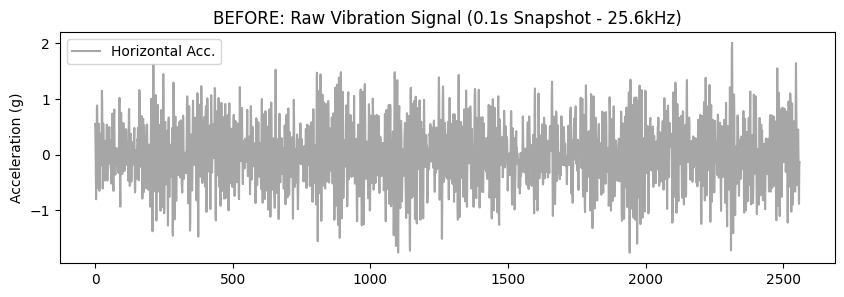

In [10]:
# Đọc thử 1 file thô (2560 mẫu trong 0.1s)
raw_sample = pd.read_csv('/content/drive/MyDrive/Bearing_Project/FEMTO-ST_Dataset/Learning_set/Bearing1_1/acc_00001.csv', header=None)
plt.figure(figsize=(10, 3))
plt.plot(raw_sample.iloc[:, 4], label='Horizontal Acc.', color='gray', alpha=0.7)
plt.title("BEFORE: Raw Vibration Signal (0.1s Snapshot - 25.6kHz)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.show()

# Dữ liệu sau khi xử lý

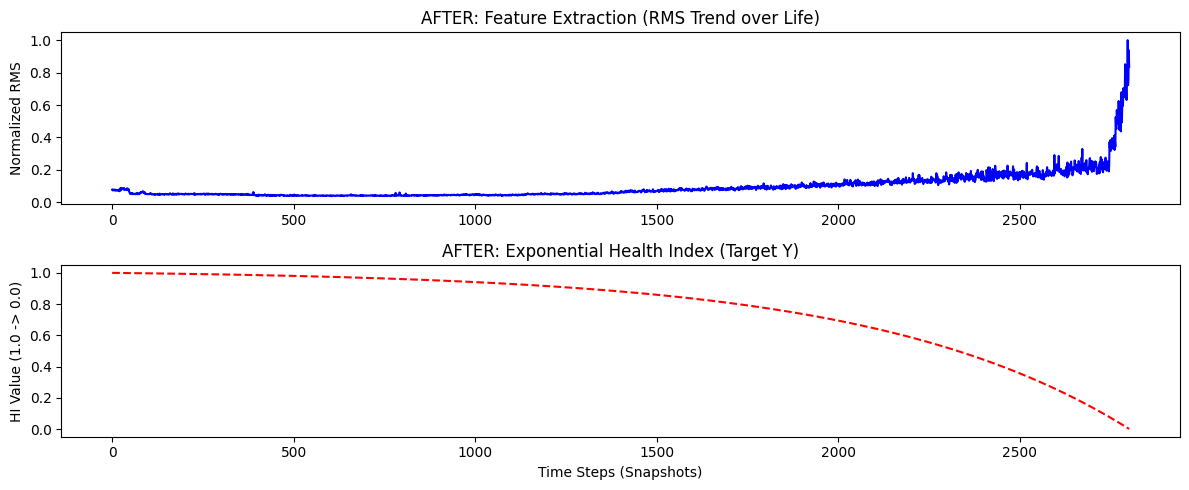

In [11]:
# Vẽ xu hướng RMS và nhãn HI hàm mũ trên toàn bộ vòng đời Bearing1_1
plt.figure(figsize=(12, 5))

# Trục 1: Đặc trưng RMS đã trích xuất
plt.subplot(2, 1, 1)
plt.plot(df_train[df_train['bearing_name']=='Bearing1_1']['h_rms'], color='blue')
plt.title("AFTER: Feature Extraction (RMS Trend over Life)")
plt.ylabel("Normalized RMS")

# Trục 2: Nhãn mục tiêu Health Index (Mô hình sẽ học cái này)
plt.subplot(2, 1, 2)
plt.plot(df_train[df_train['bearing_name']=='Bearing1_1']['HI'], color='red', linestyle='--')
plt.title("AFTER: Exponential Health Index (Target Y)")
plt.ylabel("HI Value (1.0 -> 0.0)")
plt.xlabel("Time Steps (Snapshots)")

plt.tight_layout()
plt.show()

# Xây dựng baseline model

In [12]:
# 1. MÔ HÌNH LSTM: Học phụ thuộc thời gian tuần tự
class LSTMModel(nn.Module):
    def __init__(self, input_size=6, hidden_size=32, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (Batch, 30, 6)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]) # Lấy trạng thái tại snapshot thứ 30

# 2. MÔ HÌNH TCN
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TCNModel(nn.Module):
    def __init__(self, input_size=6, output_size=1, num_channels=[16, 8], kernel_size=3):
        super(TCNModel, self).__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            padding = (kernel_size - 1) * dilation

            conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
            layers += [
                weight_norm(conv),
                Chomp1d(padding),
                nn.ReLU(),
                nn.Dropout(0.2)
            ]
        self.net = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        x = x.transpose(1, 2) # Chuyển từ (Batch, Seq, Feat) -> (Batch, Feat, Seq)
        y = self.net(x)
        return self.fc(y[:, :, -1])

# 3. MÔ HÌNH TRANSFORMER (Encoder-Only)
class TransformerModel(nn.Module):
    def __init__(self, input_size=6, d_model=16, nhead=2, num_layers=1, output_size=1):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        # Sử dụng Encoder để nén thông tin 30 snapshots thành chỉ số sức khỏe
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=32, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

# Train model

In [23]:
def train_baseline(model, train_loader, val_loader, model_name, epochs=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_loss': []}
    print(f"Training {model_name}...")

    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                v_loss += criterion(model(bx), by).item()

        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss/len(val_loader))

        if (epoch+1) % 5 == 0:
            print(f"   Epoch {epoch+1:02d}: Train Loss = {history['train_loss'][-1]:.6f} | Val Loss = {history['val_loss'][-1]:.6f}")

    return history

# Run

In [14]:
# Chuyển dữ liệu sang Tensor
train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(Y_train).view(-1, 1))
test_dataset = TensorDataset(torch.Tensor(X_test), torch.Tensor(Y_test).view(-1, 1))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Khởi tạo 3 model
models = {
    "LSTM": LSTMModel(),
    "TCN": TCNModel(),
    "Transformer": TransformerModel()
}

results = {}
for name, model in models.items():
    results[name] = train_baseline(model, train_loader, test_loader, name)

🚀 Training LSTM...
   Epoch 05: Train Loss = 0.034939 | Val Loss = 0.034814
   Epoch 10: Train Loss = 0.028431 | Val Loss = 0.036415
   Epoch 15: Train Loss = 0.024211 | Val Loss = 0.036252
   Epoch 20: Train Loss = 0.023877 | Val Loss = 0.038930
   Epoch 25: Train Loss = 0.023447 | Val Loss = 0.033381
   Epoch 30: Train Loss = 0.022866 | Val Loss = 0.036517
   Epoch 35: Train Loss = 0.023280 | Val Loss = 0.035061
   Epoch 40: Train Loss = 0.021471 | Val Loss = 0.031436
🚀 Training TCN...
   Epoch 05: Train Loss = 0.093550 | Val Loss = 0.037592
   Epoch 10: Train Loss = 0.067260 | Val Loss = 0.032799
   Epoch 15: Train Loss = 0.049375 | Val Loss = 0.031455
   Epoch 20: Train Loss = 0.037140 | Val Loss = 0.029411
   Epoch 25: Train Loss = 0.032374 | Val Loss = 0.028034
   Epoch 30: Train Loss = 0.029216 | Val Loss = 0.028088
   Epoch 35: Train Loss = 0.027959 | Val Loss = 0.028160
   Epoch 40: Train Loss = 0.027438 | Val Loss = 0.029074
🚀 Training Transformer...
   Epoch 05: Train Loss =

# Đánh giá

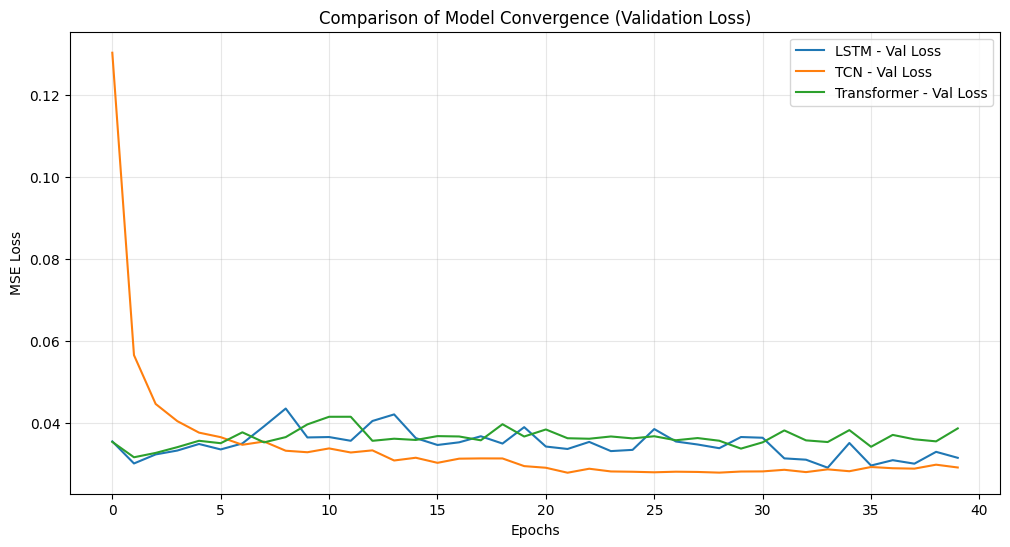

In [18]:
plt.figure(figsize=(12, 6))
for name, hist in results.items():
    plt.plot(hist['val_loss'], label=f'{name} - Val Loss')

plt.title('Comparison of Model Convergence (Validation Loss)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
def evaluate_all_models(models, df_test, feature_cols, lookback=30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    bearings = df_test['bearing_name'].unique()

    # Bảng lưu kết quả tổng hợp
    summary_data = []

    for name, model in models.items():
        model.to(device)
        model.eval()

        all_mae, all_rmse = [], []

        for b_name in bearings:
            # 1. Lấy dữ liệu từng vòng bi
            b_data = df_test[df_test['bearing_name'] == b_name]
            if len(b_data) <= lookback: continue

            feat_vals = b_data[feature_cols].values
            actual_hi = b_data['HI'].values[lookback:]

            # 2. Tạo sequences
            sequences = []
            for i in range(len(b_data) - lookback):
                sequences.append(feat_vals[i : i + lookback])

            X_input = torch.Tensor(np.array(sequences)).to(device)

            # 3. Dự báo
            with torch.no_grad():
                preds = model(X_input).cpu().numpy().flatten()

            # 4. Tính toán Metrics (trên thang đo HI 0-1)
            mae = mean_absolute_error(actual_hi, preds)
            rmse = np.sqrt(mean_squared_error(actual_hi, preds))

            all_mae.append(mae)
            all_rmse.append(rmse)

        # Tính trung bình cho model
        avg_mae = np.mean(all_mae)
        avg_rmse = np.mean(all_rmse)
        # Accuracy ước tính: 100% - (MAE * 100) -> vì dải HI là 1.0
        accuracy = max(0, 100 - (avg_mae * 100))

        summary_data.append({
            'Model': name,
            'Avg MAE (HI)': round(avg_mae, 4),
            'Avg RMSE (HI)': round(avg_rmse, 4),
            'Est. Accuracy (%)': round(accuracy, 2)
        })

    return pd.DataFrame(summary_data)

# Thực thi đánh giá
df_comparison = evaluate_all_models(models, df_test, feature_cols)

print("BẢNG SO SÁNH HIỆU SUẤT BASELINES (Trên toàn bộ 11 vòng bi Test):")
print(df_comparison.to_string(index=False))

# Xuất file CSV log
df_comparison.to_csv('/content/drive/MyDrive/Bearing_Project/baseline_comparison_log.csv', index=False)
print("\n Đã lưu kết quả vào file: baseline_comparison_log.csv")

BẢNG SO SÁNH HIỆU SUẤT BASELINES (Trên toàn bộ 11 vòng bi Test):
      Model  Avg MAE (HI)  Avg RMSE (HI)  Est. Accuracy (%)
       LSTM        0.1068         0.1500              89.32
        TCN        0.1100         0.1473              89.00
Transformer        0.1196         0.1708              88.04

 Đã lưu kết quả vào file: baseline_comparison_log.csv


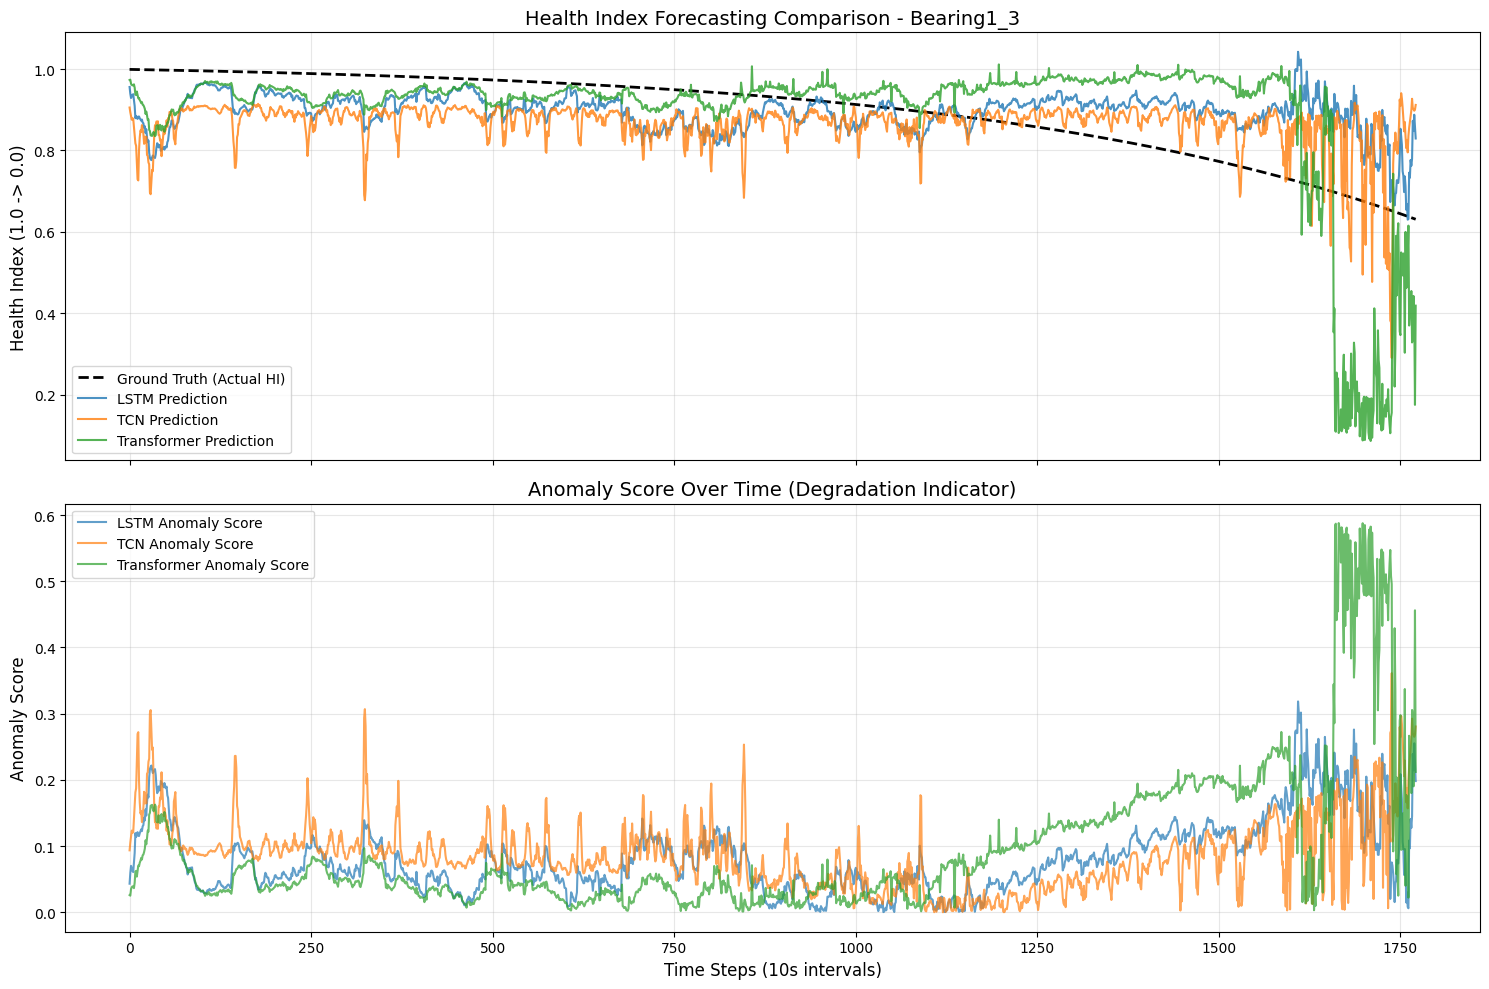

In [20]:
def visualize_comparison(models, bearing_name, df_test, feature_cols, lookback=30):
    """
    Trực quan hóa so sánh kết quả dự báo HI và Anomaly Score của các mô hình.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Lọc dữ liệu của vòng bi được chọn
    b_data = df_test[df_test['bearing_name'] == bearing_name]
    if len(b_data) <= lookback:
        print(f"Dữ liệu vòng bi {bearing_name} quá ngắn.")
        return

    feat_vals = b_data[feature_cols].values
    actual_hi = b_data['HI'].values[lookback:] # Bỏ 30 mẫu đầu để khớp window

    # 2. Tạo chuỗi đầu vào (Sequences)
    sequences = []
    for i in range(len(b_data) - lookback):
        sequences.append(feat_vals[i : i + lookback])
    X_input = torch.Tensor(np.array(sequences)).to(device)

    # 3. Vẽ biểu đồ
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    colors = {'LSTM': '#1f77b4', 'TCN': '#ff7f0e', 'Transformer': '#2ca02c'}

    # Biểu đồ 1: So sánh Health Index (Dự báo vs Thực tế)
    ax1.plot(actual_hi, label='Ground Truth (Actual HI)', color='black', linewidth=2, linestyle='--')

    # Biểu đồ 2: So sánh Anomaly Score (Sai số tuyệt đối)
    # Anomaly Score = |Dự báo - Thực tế|

    for name, model in models.items():
        model.to(device)
        model.eval()
        with torch.no_grad():
            preds = model(X_input).cpu().numpy().flatten()

        # Vẽ đường HI dự báo
        ax1.plot(preds, label=f'{name} Prediction', color=colors[name], alpha=0.8)

        # Vẽ đường Anomaly Score
        score = np.abs(actual_hi - preds)
        ax2.plot(score, label=f'{name} Anomaly Score', color=colors[name], alpha=0.7)

    # Định dạng biểu đồ trên
    ax1.set_title(f'Health Index Forecasting Comparison - {bearing_name}', fontsize=14)
    ax1.set_ylabel('Health Index (1.0 -> 0.0)', fontsize=12)
    ax1.legend(loc='lower left')
    ax1.grid(True, alpha=0.3)

    # Định dạng biểu đồ dưới
    ax2.set_title('Anomaly Score Over Time (Degradation Indicator)', fontsize=14)
    ax2.set_ylabel('Anomaly Score', fontsize=12)
    ax2.set_xlabel('Time Steps (10s intervals)', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- CHẠY THỬ NGHIỆM TRỰC QUAN ---
# Chọn một vòng bi sắp hỏng trong tập Test
visualize_comparison(models, 'Bearing1_3', df_test, feature_cols)

# Script auto

In [21]:
def calculate_full_metrics(actual_hi, pred_hi, threshold=0.15):
    """Tính toán tất cả chỉ số phát hiện bất thường theo yêu cầu."""
    scores = np.abs(actual_hi - pred_hi)
    is_anomaly_pred = scores > threshold
    is_degrading_actual = actual_hi < 0.9 # Ngưỡng sức khỏe từ tài liệu

    tp = np.sum(is_anomaly_pred & is_degrading_actual)
    fp = np.sum(is_anomaly_pred & ~is_degrading_actual)
    fn = np.sum(~is_anomaly_pred & is_degrading_actual)
    tn = np.sum(~is_anomaly_pred & ~is_degrading_actual)

    far = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Tính Detection Delay (giây)
    actual_idx = np.where(is_degrading_actual)[0]
    pred_idx = np.where(is_anomaly_pred)[0]
    delay = -1
    if len(actual_idx) > 0 and len(pred_idx) > 0:
        first_valid = pred_idx[pred_idx >= actual_idx[0]]
        if len(first_valid) > 0:
            delay = (first_valid[0] - actual_idx[0]) * 10

    return far, delay, (tp, fp, fn, tn), scores

def plot_final_dashboard(model_name, b_name, actual_hi, pred_hi, threshold=0.15):
    """Xuất bộ 3 biểu đồ: Threshold Chart, TTF% và Confusion Matrix."""
    far, delay, (tp, fp, fn, tn), scores = calculate_full_metrics(actual_hi, pred_hi, threshold)
    ttf_percent = np.linspace(0, 100, len(actual_hi))

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2)

    # 1. Anomaly Score over TTF% & Threshold Chart
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(ttf_percent, scores, label='Anomaly Score', color='darkorange', lw=2)
    ax1.axhline(y=threshold, color='red', ls='--', label=f'Detection Threshold ({threshold})')
    ax1.fill_between(ttf_percent, 0, scores, where=(scores > threshold), color='red', alpha=0.1)
    ax1.set_title(f"THRESHOLD CHART: Anomaly Score over TTF% [{model_name} - {b_name}]", fontsize=14)
    ax1.set_xlabel("Time-To-Failure Percentage (TTF%)")
    ax1.set_ylabel("Anomaly Score (|Actual - Pred|)")
    ax1.legend()

    # 2. Confusion Matrix
    ax2 = fig.add_subplot(gs[1, 0])
    cm = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax2,
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    ax2.set_title("CONFUSION MATRIX (Healthy vs Degrading)")

    # 3. Thông số kỹ thuật
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    stats = (f"RESULTS FOR {model_name}\n" + "-"*30 +
             f"\n• Detection Delay: {delay} seconds" +
             f"\n• False Alarm Rate: {far*100:.2f}%" +
             f"\n• MAE (Health Index): {mean_absolute_error(actual_hi, pred_hi):.4f}" +
             f"\n• Precision/Recall: Tập trung vào vùng Degrading")
    ax3.text(0.1, 0.5, stats, fontsize=14, family='monospace')

    plt.tight_layout()
    plt.show()

In [25]:
def run_full_automation(m_type, n_trials=10):
    def objective(trial):
        # --- THIẾT LẬP CẤU HÌNH ---
        lb = trial.suggest_int('lookback', 10, 60, step=10)
        h_dim = trial.suggest_categorical('hidden_dim', [16, 32, 64])
        lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        bs = trial.suggest_categorical('batch_size', [32, 64])

        # --- TIỀN XỬ LÝ DỮ LIỆU ĐỘNG ---
        X_tr, Y_tr = create_sequences(df_train, lookback=lb)
        X_val, Y_val = create_sequences(df_test, lookback=lb)

        train_loader = DataLoader(TensorDataset(torch.Tensor(X_tr), torch.Tensor(Y_tr).view(-1,1)),
                                  batch_size=bs, shuffle=True)
        val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(Y_val).view(-1,1)),
                                batch_size=bs, shuffle=False)

        # --- KHỞI TẠO MÔ HÌNH ---
        if m_type == 'LSTM': model = LSTMModel(6, h_dim)
        elif m_type == 'TCN': model = TCNModel(input_size=6, output_size=1, num_channels=[h_dim, h_dim//2]).to(device)
        else: model = TransformerModel(6, h_dim)

        # --- HUẤN LUYỆN VỚI VALIDATION ---
        history = train_baseline(model, train_loader, val_loader, m_type, epochs=10)

        # Optuna sẽ tối ưu hóa dựa trên Validation Loss cuối cùng
        return history['val_loss'][-1]

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

# Chạy cho cả 3 model
best_configs = {}
for m in ['LSTM', 'TCN', 'Transformer']:
    print(f"\nĐang tối ưu hóa {m} với đầy đủ Validation...")
    best_configs[m] = run_full_automation(m, n_trials=10)

[I 2026-05-06 04:26:00,933] A new study created in memory with name: no-name-9f0fe3b9-b6ec-47fc-94d3-beb83ca53dad



Đang tối ưu hóa LSTM với đầy đủ Validation...
Training LSTM...
   Epoch 05: Train Loss = 0.031909 | Val Loss = 0.032396


[I 2026-05-06 04:26:11,190] Trial 0 finished with value: 0.04018732775220073 and parameters: {'lookback': 10, 'hidden_dim': 16, 'lr': 0.001567426942830267, 'batch_size': 32}. Best is trial 0 with value: 0.04018732775220073.


   Epoch 10: Train Loss = 0.026664 | Val Loss = 0.040187
Training LSTM...
   Epoch 05: Train Loss = 0.034193 | Val Loss = 0.032281


[I 2026-05-06 04:26:16,586] Trial 1 finished with value: 0.03778410057669578 and parameters: {'lookback': 20, 'hidden_dim': 32, 'lr': 0.0008190760805086786, 'batch_size': 64}. Best is trial 1 with value: 0.03778410057669578.


...

   Epoch 10: Train Loss = 0.027707 | Val Loss = 0.040308
Training Transformer...
   Epoch 05: Train Loss = 0.028326 | Val Loss = 0.039245


[I 2026-05-06 04:30:31,011] Trial 8 finished with value: 0.03616279853468115 and parameters: {'lookback': 30, 'hidden_dim': 64, 'lr': 0.002782239644993288, 'batch_size': 32}. Best is trial 4 with value: 0.0338983597792799.


   Epoch 10: Train Loss = 0.023505 | Val Loss = 0.036163
Training Transformer...
   Epoch 05: Train Loss = 0.037024 | Val Loss = 0.029302


[I 2026-05-06 04:30:39,341] Trial 9 finished with value: 0.03450709529481953 and parameters: {'lookback': 50, 'hidden_dim': 16, 'lr': 0.0007349069868040323, 'batch_size': 64}. Best is trial 4 with value: 0.0338983597792799.


   Epoch 10: Train Loss = 0.029191 | Val Loss = 0.034507


Training Final_LSTM...
   Epoch 05: Train Loss = 0.035432 | Val Loss = 0.032504
   Epoch 10: Train Loss = 0.030850 | Val Loss = 0.035702
   Epoch 15: Train Loss = 0.026177 | Val Loss = 0.037950
   Epoch 20: Train Loss = 0.022989 | Val Loss = 0.046048
   Epoch 25: Train Loss = 0.022011 | Val Loss = 0.046179
   Epoch 30: Train Loss = 0.023110 | Val Loss = 0.037330


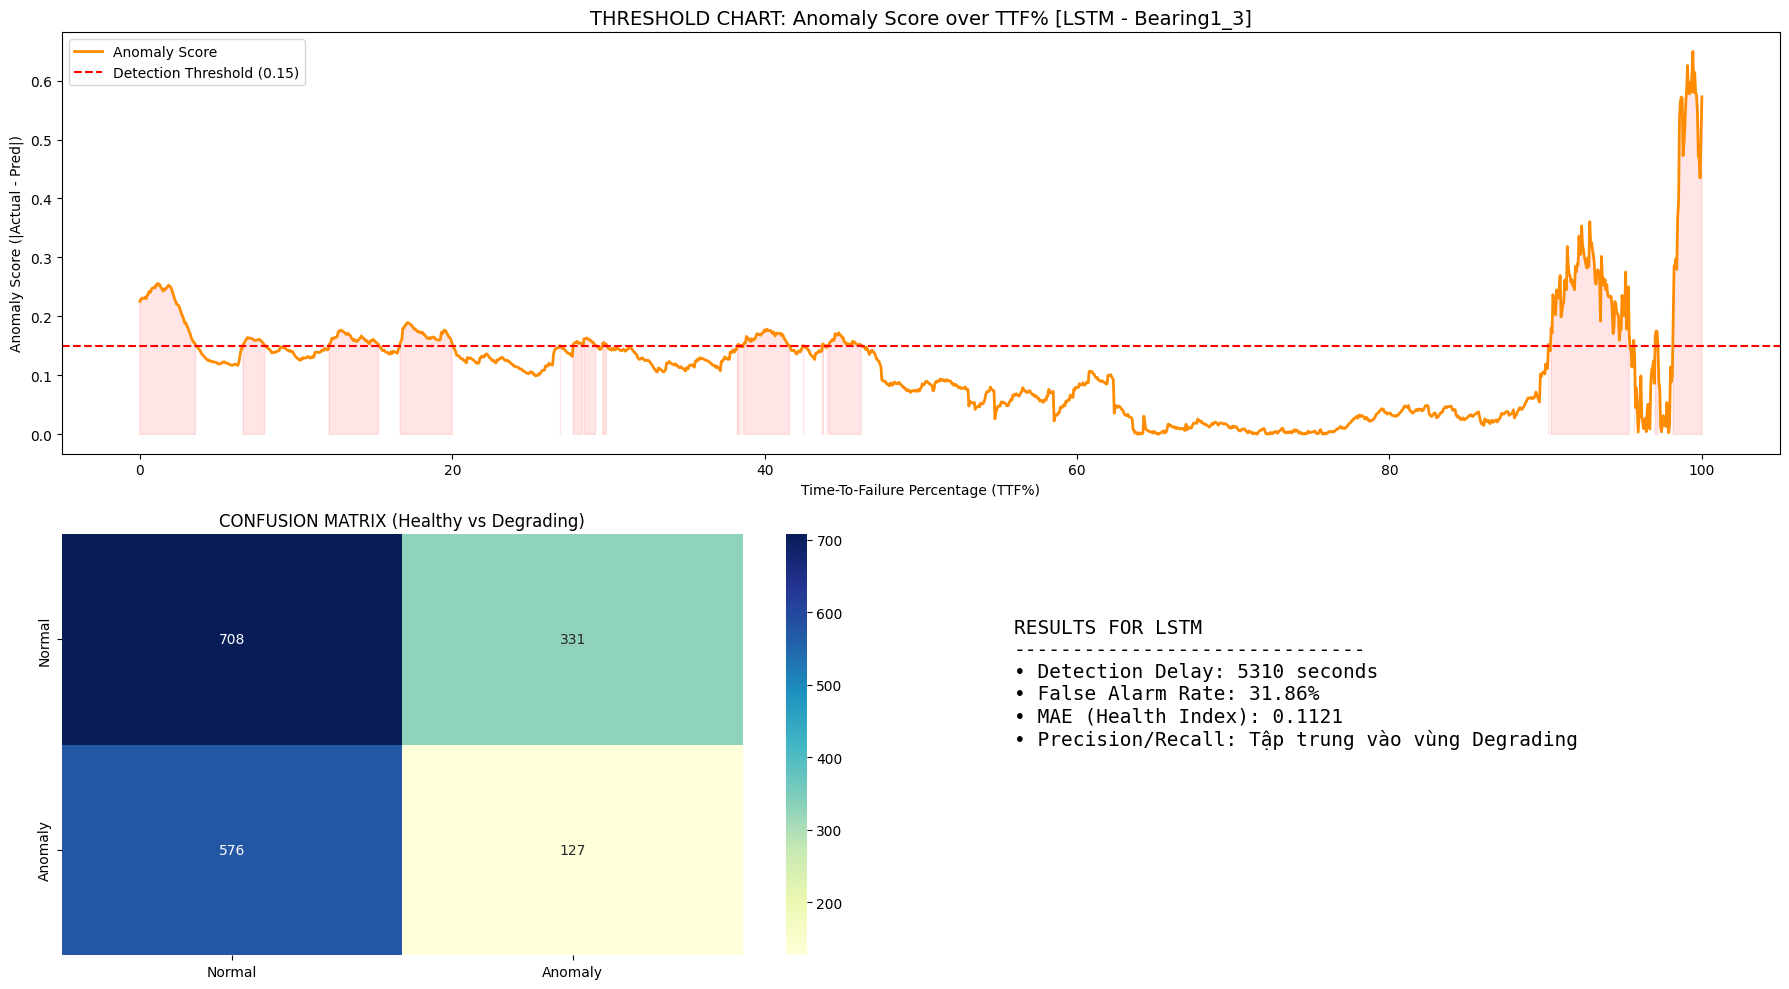

Training Final_TCN...
   Epoch 05: Train Loss = 0.049241 | Val Loss = 0.030031
   Epoch 10: Train Loss = 0.040124 | Val Loss = 0.029969
   Epoch 15: Train Loss = 0.034357 | Val Loss = 0.029450
   Epoch 20: Train Loss = 0.030159 | Val Loss = 0.028182
   Epoch 25: Train Loss = 0.027754 | Val Loss = 0.027755
   Epoch 30: Train Loss = 0.026121 | Val Loss = 0.027020


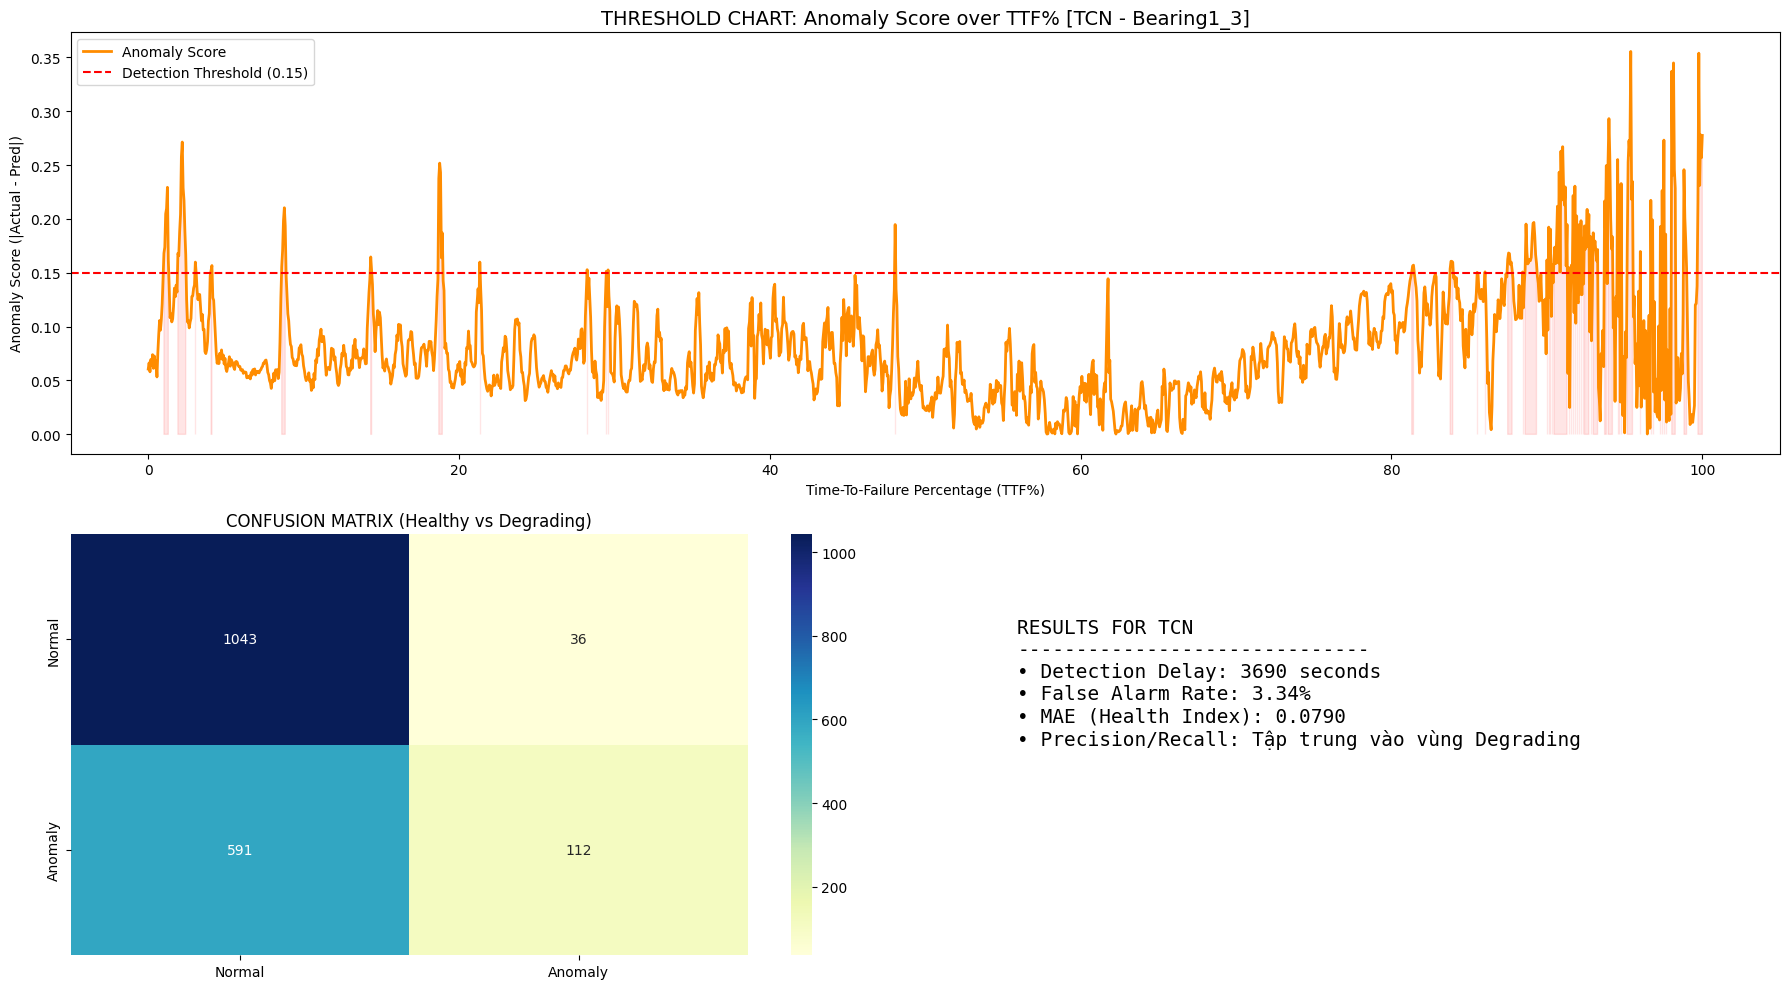

Training Final_Transformer...
   Epoch 05: Train Loss = 0.040745 | Val Loss = 0.031240
   Epoch 10: Train Loss = 0.034593 | Val Loss = 0.035976
   Epoch 15: Train Loss = 0.029497 | Val Loss = 0.038213
   Epoch 20: Train Loss = 0.025902 | Val Loss = 0.036366
   Epoch 25: Train Loss = 0.024971 | Val Loss = 0.036607
   Epoch 30: Train Loss = 0.024153 | Val Loss = 0.035936


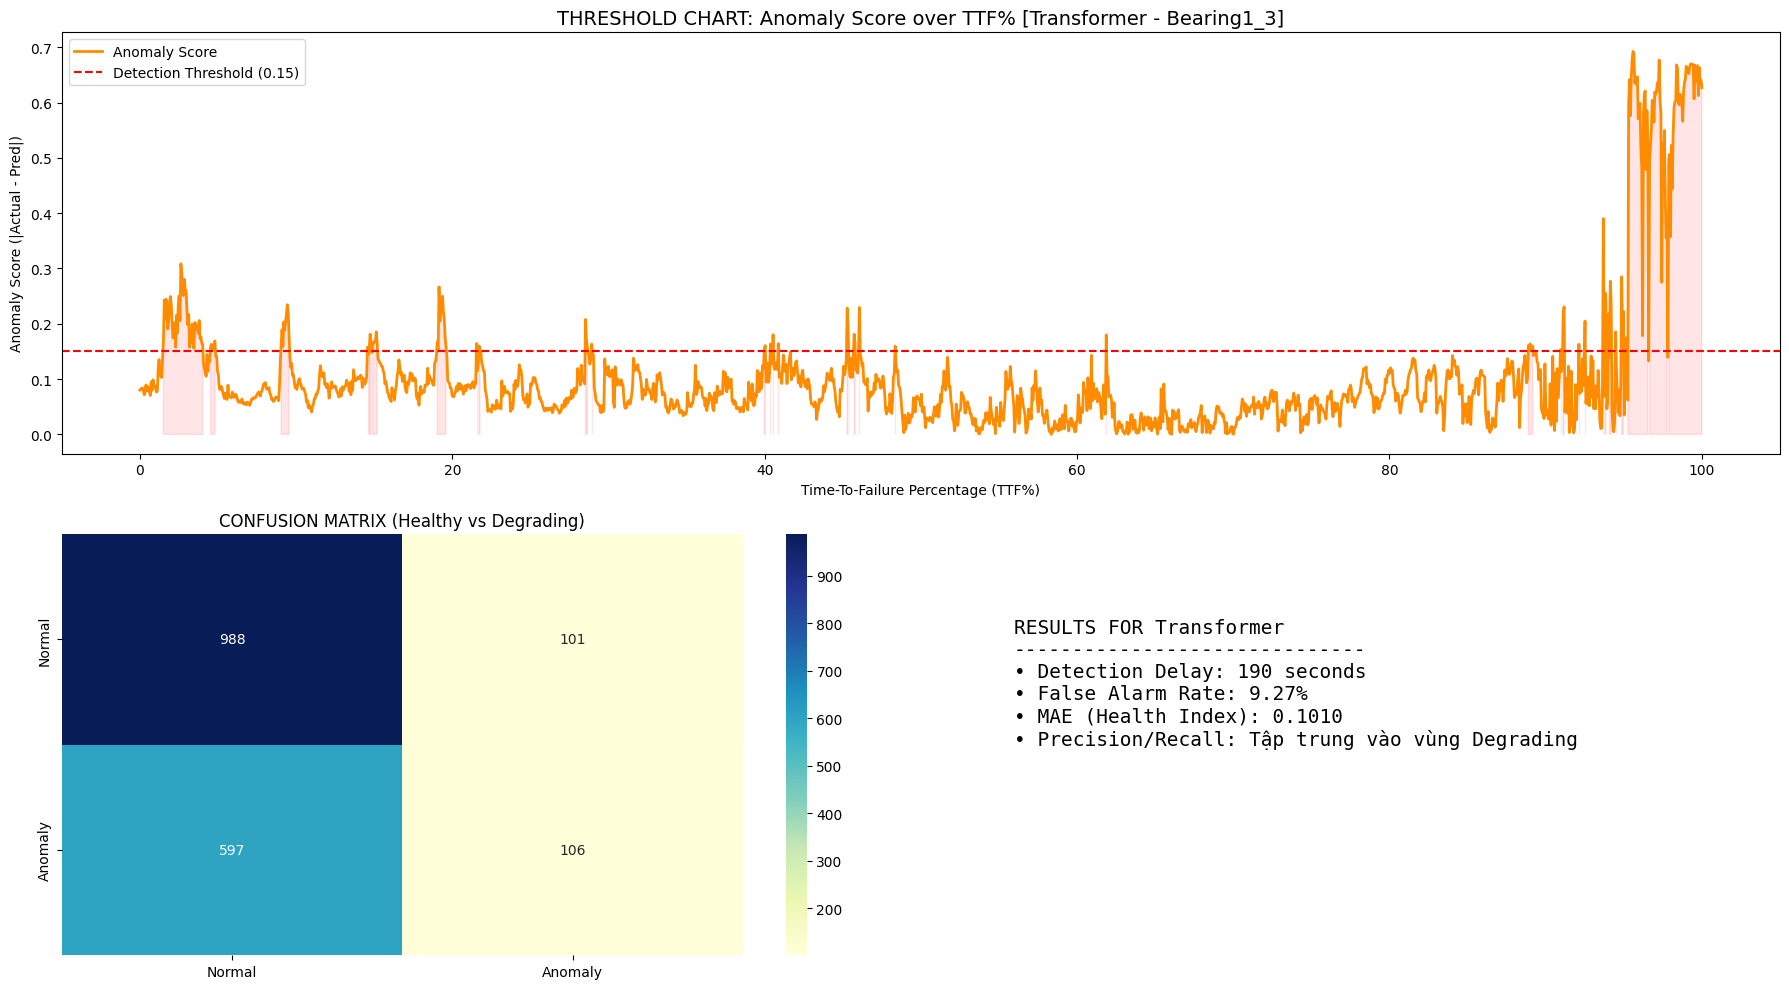

In [26]:
# Mở file CSV để ghi log báo cáo cuối cùng
with open('/content/drive/MyDrive/Bearing_Project/final_report.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'Lookback', 'Hidden_Dim', 'Delay_s', 'FAR_percent'])

for m_name, params in best_configs.items():
    lb, h_dim = params['lookback'], params['hidden_dim']

    # 1. Huấn luyện model cuối cùng
    X_tr, Y_tr = create_sequences(df_train, lookback=lb)
    X_te, Y_te = create_sequences(df_test, lookback=lb)
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_tr), torch.Tensor(Y_tr).view(-1,1)), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_te), torch.Tensor(Y_te).view(-1,1)), batch_size=64, shuffle=False)

    # Khởi tạo lại kiến trúc model
    if m_name == 'LSTM': model = LSTMModel(6, h_dim)
    elif m_name == 'TCN': model = TCNModel(input_size=6, output_size=1, num_channels=[h_dim, h_dim//2]).to(device)
    else: model = TransformerModel(6, h_dim)

    # Train kỹ hơn (30 epochs)
    train_baseline(model, train_loader, val_loader, f"Final_{m_name}", epochs=30)

    # 2. Dự báo trên một vòng bi cụ thể để làm báo cáo trực quan (Ví dụ Bearing1_3)
    b_name = 'Bearing1_3'
    b_data = df_test[df_test['bearing_name'] == b_name]
    feat_vals = b_data[feature_cols].values
    seqs = torch.Tensor(np.array([feat_vals[i:i+lb] for i in range(len(b_data)-lb)])).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(seqs).cpu().numpy().flatten()
    actual_hi = b_data['HI'].values[lb:]

    # 3. XUẤT ĐẦY ĐỦ DASHBOARD YÊU CẦU
    plot_final_dashboard(m_name, b_name, actual_hi, preds, threshold=0.15)

    # 4. Lưu vào log CSV
    far, delay, _, _ = calculate_full_metrics(actual_hi, preds)
    with open('/content/drive/MyDrive/Bearing_Project/final_report.csv', 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([m_name, lb, h_dim, delay, far*100])